## Вариант 7

Рассмотреть динамику одномерного дискретного отображения
$$x_{n+1} = x_n^3 - 1.8x_n + r, \quad r \in [-1.5, 1.5]$$

**Нужно:**

*   Построить бифуркационную диаграмму отображения при изменении параметра $r$ на заданном интервале.
*   Выбрать несколько (3–4) характерных значений параметра $r$, при которых динамика отображения качественно различается (например: устойчивое равновесие, периодические циклы, хаос).
*   Для выбранных значений $r$ построить итерационные диаграммы и график $x_n$ от номера итерации $n$.
*   Построить график зависимости показателя Ляпунова от параметра $r$.
*   Для выбранных значений $r$ найти стационарные точки и рассмотреть их устойчивость (здесь уравнения для них в основном решаются численно, например, методом Ньютона).

In [55]:
import numpy as np
import matplotlib.pyplot as plt

r_min, r_max = -1.5, 1.5

def f(x_n: float | np.ndarray, r: float | np.ndarray) -> float | np.ndarray:
    return x_n**3 - 1.8 * x_n + r



C:\Users\andre\AppData\Local\Temp\ipykernel_26872\3224551177.py:7: RuntimeWarning: overflow encountered in power
  return x_n**3 - 1.8 * x_n + r
C:\Users\andre\AppData\Local\Temp\ipykernel_26872\3224551177.py:7: RuntimeWarning: invalid value encountered in subtract
  return x_n**3 - 1.8 * x_n + r


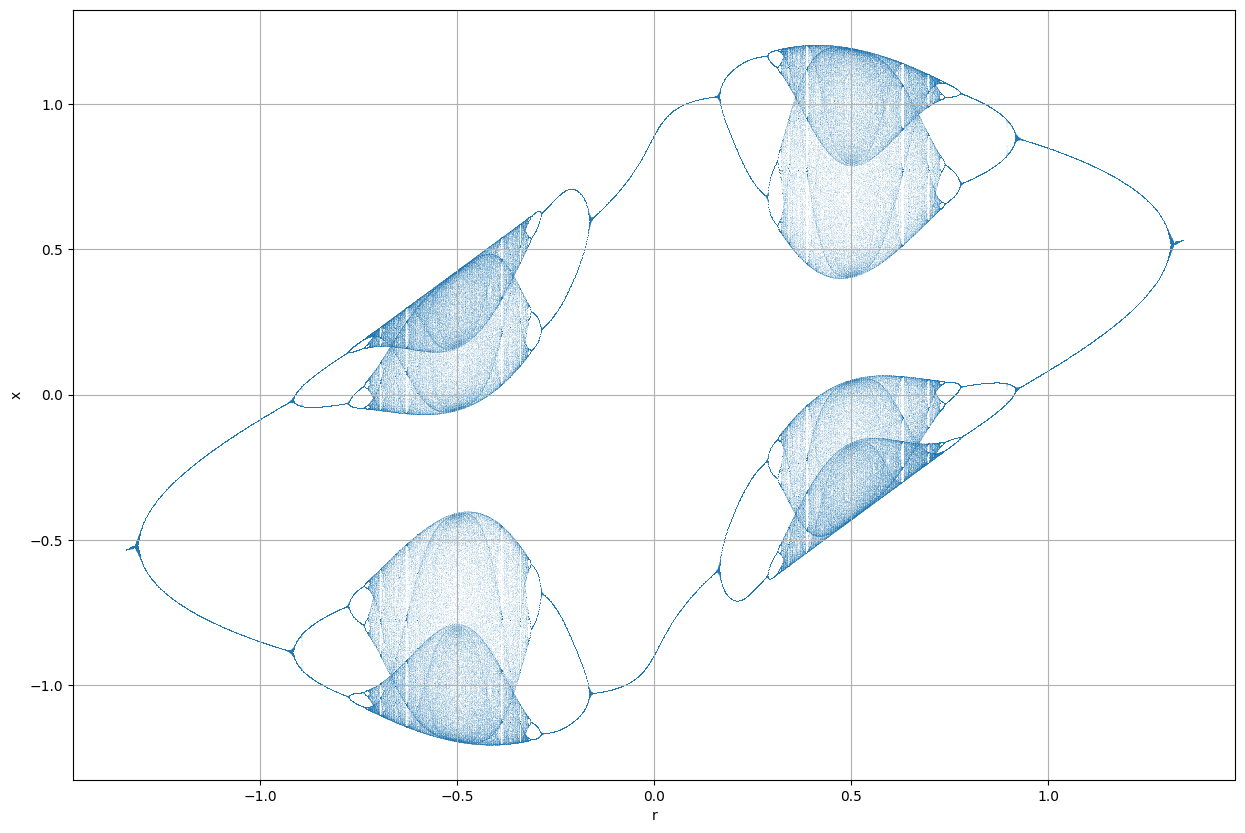

In [56]:
def create_diagram(x_0: float, r: np.ndarray, epoch: int = 500, init_epoch: int=100) -> np.ndarray:
    field = []
    x = np.full(r.shape[0], x_0)
    for _ in range(init_epoch + epoch):
        x = f(x, r)
        field.append(x)
    
    return np.array(field[init_epoch:])

x_0 = 0
h = 0.001
r = np.arange(r_min, r_max, h)
diagram = create_diagram(x_0, r)

x, y = np.tile(r, diagram.shape[0]), diagram.ravel()
plt.figure(figsize=(15, 10))
plt.scatter(x, y, s=0.1, alpha=0.3, linewidths=0)
plt.xlabel("r")
plt.ylabel("x")
plt.grid(True)
plt.show()

Выберем следующие $r$ при $x_0 = 0$:
1) $r = -1.33$ - аттрактор
2) $r = 0.1$ - предельный цикл
3) $r = -0.5$ - хаос

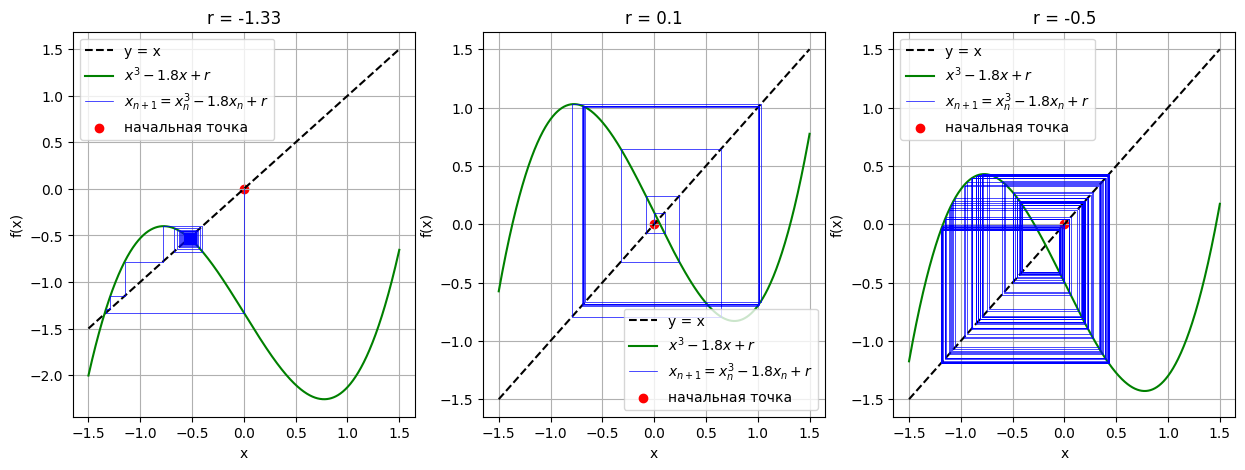

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def analitic_f(x, r):
    return x**3 - 1.8 * x + r

def draw_ladder(ax, f, x_0, r, max_iter=100, **kwargs):
    x = []
    x.append((x_0, x_0))
    for _ in range(max_iter):
        f_n = f(x[-1][1], r)
        x.append((x[-1][0], f_n))
        x.append((f_n, f_n))
    x = np.array(x)
    ax.plot(x[:, 0], x[:, 1], **kwargs)

def draw_fx(ax, f, x, x_0, r):
    ax.plot(x, x, label='y = x', linestyle='--', color='black')
    ax.plot(x, analitic_f(x, r), label=r'$x^3 - 1.8x + r$', color='green')
    draw_ladder(ax, f, x_0, r, label=r'$x_{n+1} = x_n^3 - 1.8x_n + r$', color='blue', linewidth=0.5)
    ax.scatter(x_0, x_0, label='начальная точка', color='red')
    ax.legend()
    ax.grid(True)
    ax.set_title(f'r = {r}')
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')


x = np.linspace(-1.5, 1.5, 1000)
r_1, r_2, r_3 = -1.33, 0.1, -0.5

draw_fx(axes[0], f, x, x_0, r_1)
draw_fx(axes[1], f, x, x_0, r_2)
draw_fx(axes[2], f, x, x_0, r_3)

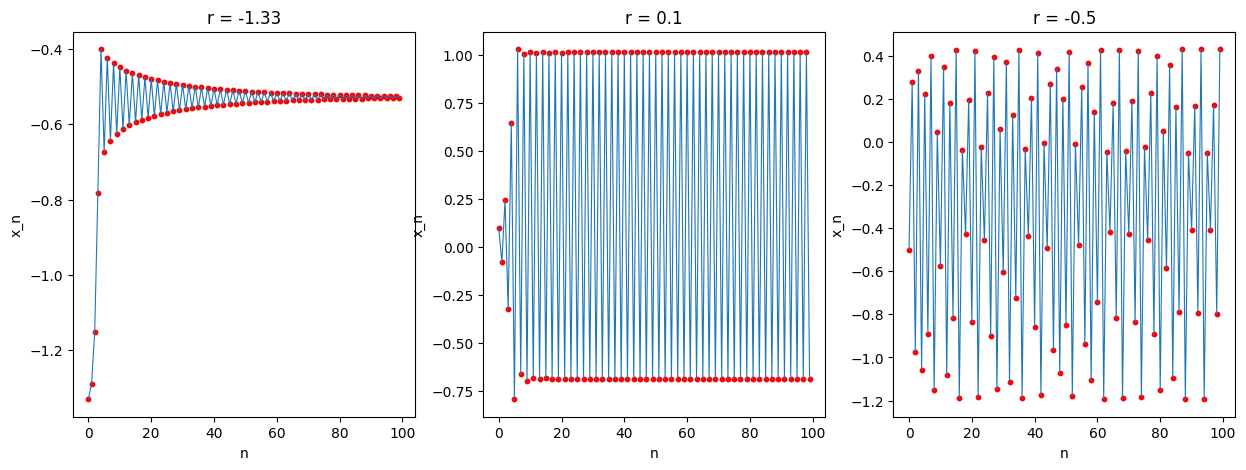

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def solve(f, x0, r, max_iter=100):
    x = []
    x.append(x0)
    for _ in range(max_iter):
        x.append(f(x[-1], r))
    return np.array(x)

def draw_xn(ax, f, x_0, r, n=100):
    ax.plot(np.arange(n), solve(f, x_0, r, n)[1:], linewidth=0.8)
    ax.scatter(np.arange(n), solve(f, x_0, r, n)[1:], color='red', s=10)
    ax.set_title(f'r = {r}')
    ax.set_xlabel('n')
    ax.set_ylabel('x_n')

draw_xn(axes[0], f, x_0, r_1)
draw_xn(axes[1], f, x_0, r_2)
draw_xn(axes[2], f, x_0, r_3)


C:\Users\andre\AppData\Local\Temp\ipykernel_26872\3224551177.py:7: RuntimeWarning: overflow encountered in scalar power
  return x_n**3 - 1.8 * x_n + r
C:\Users\andre\AppData\Local\Temp\ipykernel_26872\3224551177.py:7: RuntimeWarning: invalid value encountered in scalar subtract
  return x_n**3 - 1.8 * x_n + r
C:\Users\andre\AppData\Local\Temp\ipykernel_26872\3224551177.py:7: RuntimeWarning: overflow encountered in power
  return x_n**3 - 1.8 * x_n + r
C:\Users\andre\AppData\Local\Temp\ipykernel_26872\3224551177.py:7: RuntimeWarning: invalid value encountered in subtract
  return x_n**3 - 1.8 * x_n + r


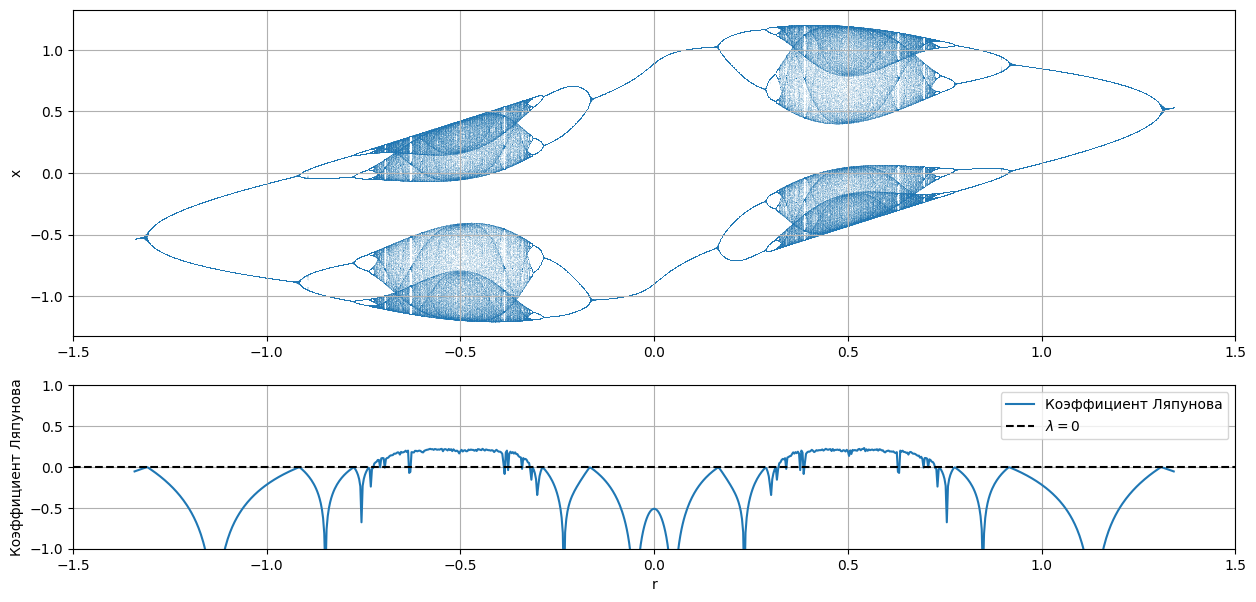

In [67]:
fig, axes = plt.subplots(2, 1, figsize=(15, 7), gridspec_kw={'height_ratios': [2, 1]})

def lyapunov_coef(f, x0, r, n=1000, burn=1000):
    x = solve(f, x0, r, n + burn)
    x = x[burn:]
    dfdx = 3 * x[:-1]**2 - 1.8
    return np.mean(np.log(np.abs(dfdx)))

r = np.linspace(-1.5, 1.5, 1000)
lyapunov_coefs = np.array([lyapunov_coef(f, x_0, r_i) for r_i in r])

axes[1].plot(r, lyapunov_coefs, label='Коэффициент Ляпунова')
axes[1].plot(r, np.zeros_like(r), label=r'$\lambda=0$', linestyle='--', color='black')
axes[1].legend()
axes[1].set_xlim(r_min, r_max)
axes[1].set_ylim(-1, 1)
axes[1].set_xlabel('r')
axes[1].set_ylabel('Коэффициент Ляпунова')
axes[1].grid(True)

r = np.arange(r_min, r_max, h)
diagram = create_diagram(x_0, r)

x, y = np.tile(r, diagram.shape[0]), diagram.ravel()
axes[0].scatter(x, y, s=0.1, alpha=0.3, linewidths=0)
axes[0].set_xlim(r_min, r_max)
axes[0].set_ylabel("x")
axes[0].grid(True)

Найдем стационарные точки для
1) $r = -1.33$ - аттрактор
2) $r = 0.1$ - предельный цикл

In [92]:
def find_points(f, r, eps=1e-8, epochs=10000):
    x_0 = np.random.normal()
    x = [x_0]
    for _ in range(epochs):
        x.append(f(x[-1], r))
    
    points = [x[-1]]
    def simular_in(x, array, eps) -> bool:
        for y in array:
            if abs(x - y) < eps:
                return True
        return False

    i = len(x) - 2
    while not simular_in(x[i], points, eps):
        points.append(x[i])
        i -= 1
    return points

points_1 = find_points(f, r_1)
lapunov_1 = lyapunov_coef(f, points_1[0], r_1)
print(f"Стационарные точки для r = {r_1}: {points_1}, коэффициент Ляпунова: {lapunov_1}")

points_2 = find_points(f, r_2)
lapunov_2 = lyapunov_coef(f, points_2[0], r_2)
print(f"Стационарные точки для r = {r_2}: {points_2}, коэффициент Ляпунова: {lapunov_2}")

Стационарные точки для r = -1.33: [-0.5273881514177219], коэффициент Ляпунова: -0.03502092286972649
Стационарные точки для r = 0.1: [-0.6854669005841149, 1.011763603687781], коэффициент Ляпунова: -0.35038409084428623
